<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/02_arima_price_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ARIMA Time-Series Model

The objective of this project is to forecast the short-term closing price of NVIDIA (NVDA) stock using classical time-series models and compare their performance using information criteria and forecast accuracy.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import os
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/stocks'
os.makedirs(folder_path, exist_ok=True)

assets_folder_path = '/content/drive/MyDrive/stocks/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Mounted at /content/drive


#### Load NVDA price and volume and merge them together

In [ ]:
# --- Load the clean and flatten file ---
all_stocks_ready_2021_2026_path = os.path.join(folder_path, 'all_stocks_ready_2021_2026.csv')

all_stocks_ready_2021_2026_df = pd.read_csv(all_stocks_ready_2021_2026_path,
    index_col='Date',
    parse_dates=True
)

all_stocks_ready_2021_2026_df

# Filter out only 'close' related columns
close_df = all_stocks_ready_2021_2026_df.filter(like='_close').copy()
close_df

,nvda_close,qqq_close,tnx_close,tsm_close,amd_close,vix_close
Date,,,,,,
2021-01-04,13.076726,300.163086,0.917,102.714409,92.300003,26.969999
2021-01-05,13.367159,302.637695,0.955,103.698341,92.769997,25.340000
2021-01-06,12.579126,298.445435,1.042,106.309875,90.330002,25.070000
2021-01-07,13.306578,305.665466,1.071,111.661697,95.160004,22.370001
2021-01-08,13.239518,309.595673,1.105,109.142136,94.580002,21.559999
...,...,...,...,...,...,...
2026-01-29,192.509995,629.429993,4.227,339.549988,252.179993,16.879999
2026-01-30,191.130005,621.869995,4.241,330.559998,236.729996,17.440001
2026-02-02,185.610001,626.140015,4.275,341.359985,246.270004,16.340000


#### The result shows the DataFrame has 1278 entries and 6 columns with no null values.

In [ ]:
# Copy the dataframe for reference and extract nvda close
nvda = close_df[['nvda_close']].copy()

# Double check ot make sure index is sorted chronologically to preserve temporal order.
nvda = nvda.sort_index()

#### Define the prediction task

This project focuses on classical time-series forecasting methods demonstrated in class, comparing ARIMA, Prophet, and linear trend models using AIC and forecast error metrics.

In [ ]:
arima_ts = nvda['nvda_close']
arima_ts.index = pd.to_datetime(arima_ts.index) # Make sure arima_ts has a datetime index
arima_ts = arima_ts.asfreq('B') # Only business work days (M-F)
arima_ts

,nvda_close
Date,
2021-01-04,13.076726
2021-01-05,13.367159
2021-01-06,12.579126
2021-01-07,13.306578
2021-01-08,13.239518
...,...
2026-01-29,192.509995
2026-01-30,191.130005
2026-02-02,185.610001


#### ARIMA (Autoregressive Integrated Moving Average)

##### The ARIMA (Autoregressive Integrated Moving Average) model is a commonly used approach for forecasting time-series data. It works by combining information from past values of the series, changes between observations, and past forecast errors to model the underlying structure of the data. By incorporating **autoregression (AR), differencing (I), and moving-average terms (MA)**, ARIMA is able to capture trends and short-term patterns in historical data and use them to generate future forecasts.




#### ADF Differencing
Because ARIMA models require a stationary time series, the stationarity of the NVDA closing price data is first evaluated using the **Augmented Dickey–Fuller (ADF)** test. The ADF test checks for the presence of a unit root, where a failure to reject the null hypothesis indicates non-stationarity and the need for differencing before model fitting.

The test result shows the p-value (.97) is > .05 and the test statistic is above all critical values, so it fails to reject the null hypothesis. In other words, NVDA closing pric series is non-stationary.

To address this, first differencing is applied, which removes trend effects by modeling changes between consecutive observations rather than absolute price levels.

In [ ]:
adfuller(arima_ts.diff().dropna())
print(adfuller(arima_ts.diff().dropna())[1])

1.3077921018663506e-07


After differencing, the ADF test strongly rejected the null hypothesis (p < 0.001) and that the transformed series now is stationary.
This proves that the first differencing is required to satisfy the assumptions of ARIMA modeling, corresponding to d = 1 in the ARIMA(p, d, q) specification.

#### Autoregressive (AR) Models - obtain d

In [ ]:
arima_ts_diff = arima_ts.diff().dropna()
arima_ts_diff

,nvda_close
Date,
2021-01-05,0.290433
2021-01-06,-0.788033
2021-01-07,0.727451
2021-01-08,-0.067060
2021-01-11,0.343784
...,...
2026-01-29,0.989990
2026-01-30,-1.379990
2026-02-02,-5.520004


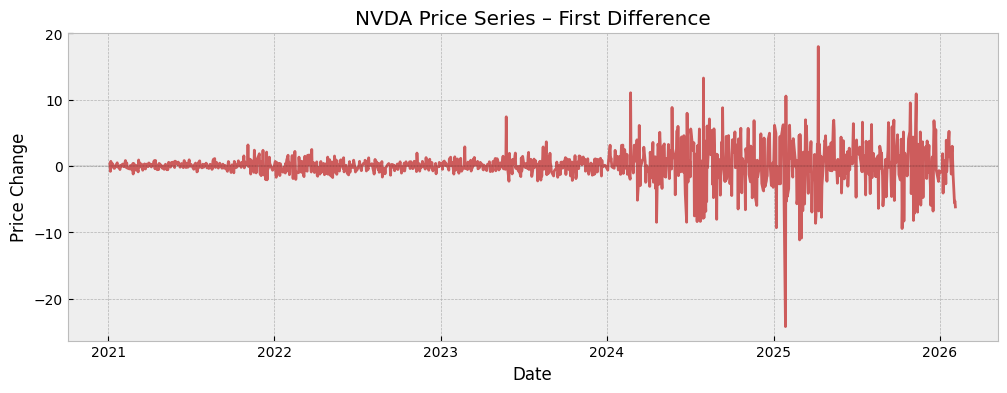

In [ ]:
plt.figure(figsize=(12,4))
plt.style.use('bmh')
plt.plot(arima_ts_diff, color='indianred')
plt.axhline(0, color='black', linestyle='--', linewidth=.2)
plt.title("NVDA Price Series – First Difference")
plt.ylabel("Price Change")
plt.xlabel("Date")
plt.grid(True)
plt.show()

##### After differencing, the series fluctuates around 0, which indicates the evidence of stationarity. The strong upward long-term trend in nvda price disappears. Variance increases and volatility clusters towards later in the series.

#### ACF/PACF - Candidate p, q

Text(0, 0.5, 'Correlation')

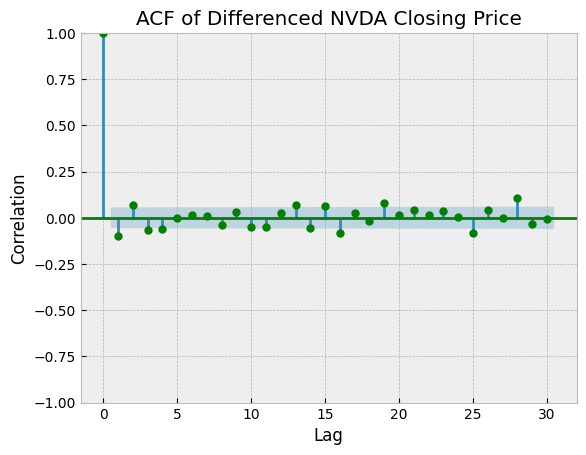

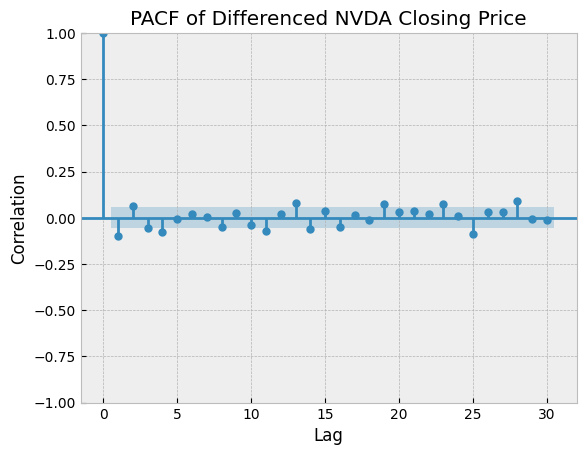

In [ ]:
plot_acf(arima_ts_diff, lags=30, color='green')
plt.title('ACF of Differenced NVDA Closing Price')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plot_pacf(arima_ts_diff, lags=30)
plt.title('PACF of Differenced NVDA Closing Price')
plt.xlabel('Lag')
plt.ylabel('Correlation')


#### ACF Plot Interpretation:
* Low Autocorrelation: Since all lag correlations are close to zero, this suggests that the series is likely to be white noise or has very short memory. There are no lags showing significant autocorrelation.
* Model Implications: If ACF does not show significant spikes, it indicates that you might consider a lower or possibly no moving average (MA) component.

### Interpretation of the ACF Plot:
Low Autocorrelation: Since all lag correlations are close to zero, this suggests that the series is likely to be white noise or has very short memory. There are no lags showing significant autocorrelation.
*Model Implications: If ACF does not show significant spikes, it indicates that you might consider a lower or possibly no moving average (MA) component.

After first differencing, both the ACF and PACF exhibit minimal autocorrelation, with no strong spikes beyond lag 1. This indicates that the differenced series behaves similarly to white noise, which is typical for financial return data. A parsimonious ARIMA(1,1,1) model is therefore selected to capture any remaining short-term dependence.

#### AIC Grid Search - to obtain p, d, q

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA

best_aic = np.inf
best_order = None

# for the AR compnent (p)
for p in range(5):
    for q in range(5):
        try:
            model = ARIMA(arima_ts, trend='t', order=(p,1,q)) # Add a trend element
            fit = model.fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p,1,q)
        except:
            continue

print("Best:", best_order, "AIC:", best_aic);

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best: (4, 1, 4) AIC: 6018.633326055835


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


While ARIMA(4,1,4) achieved the lowest AIC, a simpler ARIMA(1,1,1) model was selected due to its interpretability and stability, given the weak autocorrelation structure of the differenced series.

Best model = ARIMA(4, 1, 4)

#### Refit the Model Using Only the Training Data
##### Train-Test-Split

In [ ]:
# Test for one full year
split_date = pd.to_datetime('02-03-2025') # First business date in Feb 2025

arima_train = arima_ts[arima_ts.index < split_date]
arima_test =  arima_ts[arima_ts.index >= split_date]

#### ARIMA Fit Train Data Only

In [ ]:
arima_train_model = ARIMA(arima_train, order =(4,1,4), trend='t')
arima_train_fit= arima_train_model.fit()
arima_train_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             nvda_close   No. Observations:                 1065
Model:                 ARIMA(4, 1, 4)   Log Likelihood               -2201.448
Date:                Fri, 06 Mar 2026   AIC                           4422.896
Time:                        21:05:02   BIC                           4472.594
Sample:                    01-04-2021   HQIC                          4441.728
                         - 01-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0970      0.118      0.822      0.411      -0.134       0.328
ar.L1          0.0738      0.098      0.755      0.450      -0.118       0.265
ar.L2          1.3527      0.077     17.468      0.000       1.201       1.505
ar.L3          0.3706      0.072      5.137      0.000       0.229       0.512
ar.L4         -0.8018      0.095     -8.403      0.000      -0.989      -0.615
ma.L1         -0.1285      0.092     -1.396      0.163      -0.309       0.052
ma.L2         -1.3276      0.070    -19.087      0.000      -1.464      -1.191
ma.L3         -0.3760      0.067     -5.577      0.000      -0.508      -0.244
ma.L4          0.8366      0.089      9.401      0.000       0.662       1.011
sigma2         4.1702      0.085     48.826      0.000       4.003       4.338
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             18494.93
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):              19.24   Skew:                            -1.05
Prob(H) (two-sided):                  0.00   Kurtosis:                        23.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Diagnostic Check (still in-sample)
##### Chart fit.resid

In [ ]:
resid = arima_train_fit.resid.dropna()
resid

,0
Date,
2021-01-04,12.979733
2021-01-05,0.193448
2021-01-06,-0.858140
2021-01-07,0.503233
2021-01-08,-0.026412
...,...
2025-01-27,-22.472330
2025-01-28,6.960044
2025-01-29,-2.446821


#### The residual dignostic chart checks training assumptions and validate the residual patterns are just white noise and that (4, 1,4) is not underfitting

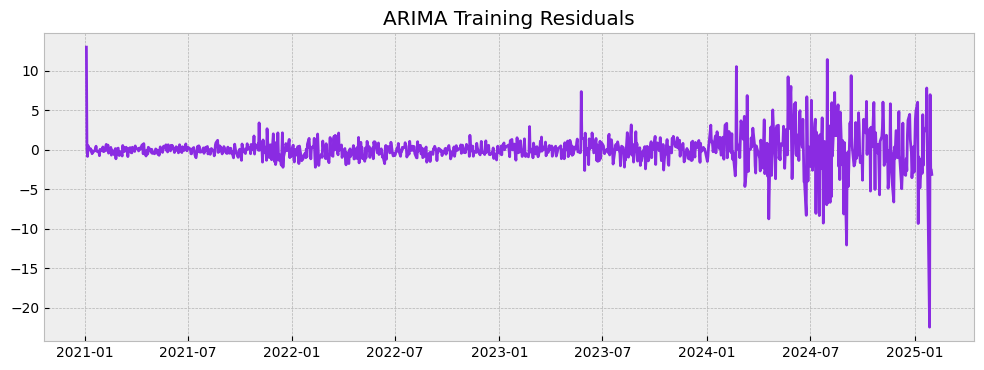

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(resid, color='blueviolet')
# plt.plot(resid, color='firebrick')
plt.title('ARIMA Training Residuals')
plt.show()

#### Plot acf and pact of fit.resid

<Figure size 1000x400 with 0 Axes>

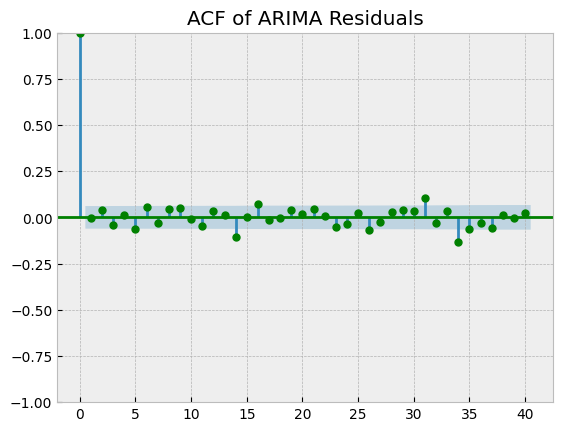

<Figure size 1000x400 with 0 Axes>

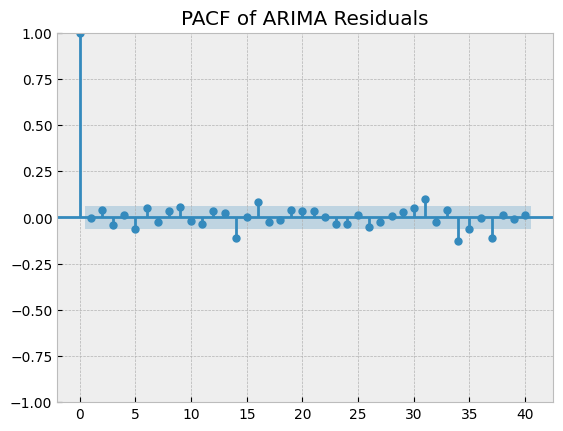

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(resid, lags=40,color='green')
plt.title('ACF of ARIMA Residuals')
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(resid, lags=40)
plt.title('PACF of ARIMA Residuals')
plt.show()

In [ ]:
forecast = arima_train_fit.get_forecast(steps=len(arima_test))
pred = forecast.predicted_mean
pred


,predicted_mean
2025-02-03,121.034183
2025-02-04,122.523672
2025-02-05,120.548861
2025-02-06,123.886394
2025-02-07,121.214328
...,...
2026-01-29,147.700595
2026-01-30,147.343912
2026-02-02,147.864430
2026-02-03,147.668969


In [ ]:
print(f'arima_test has: {arima_test.isnull().sum()} NaNs')
print(f'pred has: {pred.isnull().sum()} NaNs')

# arima_test set has NaN because of market holidays.
# pred has no NaNs because ARIMA predicts every step

arima_test_clean = arima_test.dropna()
pred_clean = pred.loc[arima_test_clean.index]


arima_test has: 10 NaNs
pred has: 0 NaNs


##### Remove market holidays from ARIMA train dataset

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def evaluate_arima(train, test, fit, model_name='ARIMA'):

    # ----- In-sample -----
    train_pred = fit.fittedvalues
    train_eval = pd.concat([train, train_pred], axis=1).dropna()
    train_eval.columns = ['actual', 'pred']

    # ----- Out-of-sample -----
    forecast = fit.get_forecast(steps=len(test))
    test_pred = forecast.predicted_mean

    test_eval = pd.concat([test, test_pred], axis=1).dropna()
    test_eval.columns = ['actual', 'pred']

    # ----- Metrics -----
    results = {
        'Model': model_name,
        'Train_MAE': mean_absolute_error(train_eval['actual'], train_eval['pred']),
        'Test_MAE': mean_absolute_error(test_eval['actual'], test_eval['pred']),
        'Train_RMSE': np.sqrt(mean_squared_error(train_eval['actual'], train_eval['pred'])),
        'Test_RMSE': np.sqrt(mean_squared_error(test_eval['actual'], test_eval['pred'])),
        'Train_MAPE': mean_absolute_percentage_error(train_eval['actual'], train_eval['pred']),
        'Test_MAPE': mean_absolute_percentage_error(test_eval['actual'], test_eval['pred'])
    }

    return pd.DataFrame([results])


In [ ]:
arima_metrics_export = evaluate_arima(
    arima_train,
    arima_test,
    arima_train_fit,
    model_name='ARIMA'
)

display(arima_metrics_export)

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,ARIMA,1.190692,29.419806,2.122741,33.329724,0.026582,0.17674


In [ ]:
file_path = os.path.join(folder_path, 'arima_results.csv')
arima_metrics_export.to_csv(file_path, index=False)

print("Saved to:", file_path)

Saved to: /content/drive/MyDrive/stocks/arima_results.csv


#### Get ARIMA forecast for the full dataset

In [ ]:
arima_full_model = ARIMA(
    arima_ts,
    order=(4,1,4),   # use the order selected
    trend='t'
)

arima_full_fit = arima_full_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Forecast next 30 business days

In [ ]:
arima_forecast_30 = arima_full_fit.get_forecast(steps=30)
pred_30 = arima_forecast_30.predicted_mean
ci_30 = arima_forecast_30.conf_int()

In [ ]:
pred_30

,predicted_mean
2026-02-05,174.381767
2026-02-06,174.421509
2026-02-09,175.603395
2026-02-10,175.715625
2026-02-11,175.459187
2026-02-12,175.995281
2026-02-13,176.625375
2026-02-16,176.358666
2026-02-17,176.355110
2026-02-18,176.997817


#### NVDA Price History + Forecast Window
Forecast window highlighted in the final portion of the series.

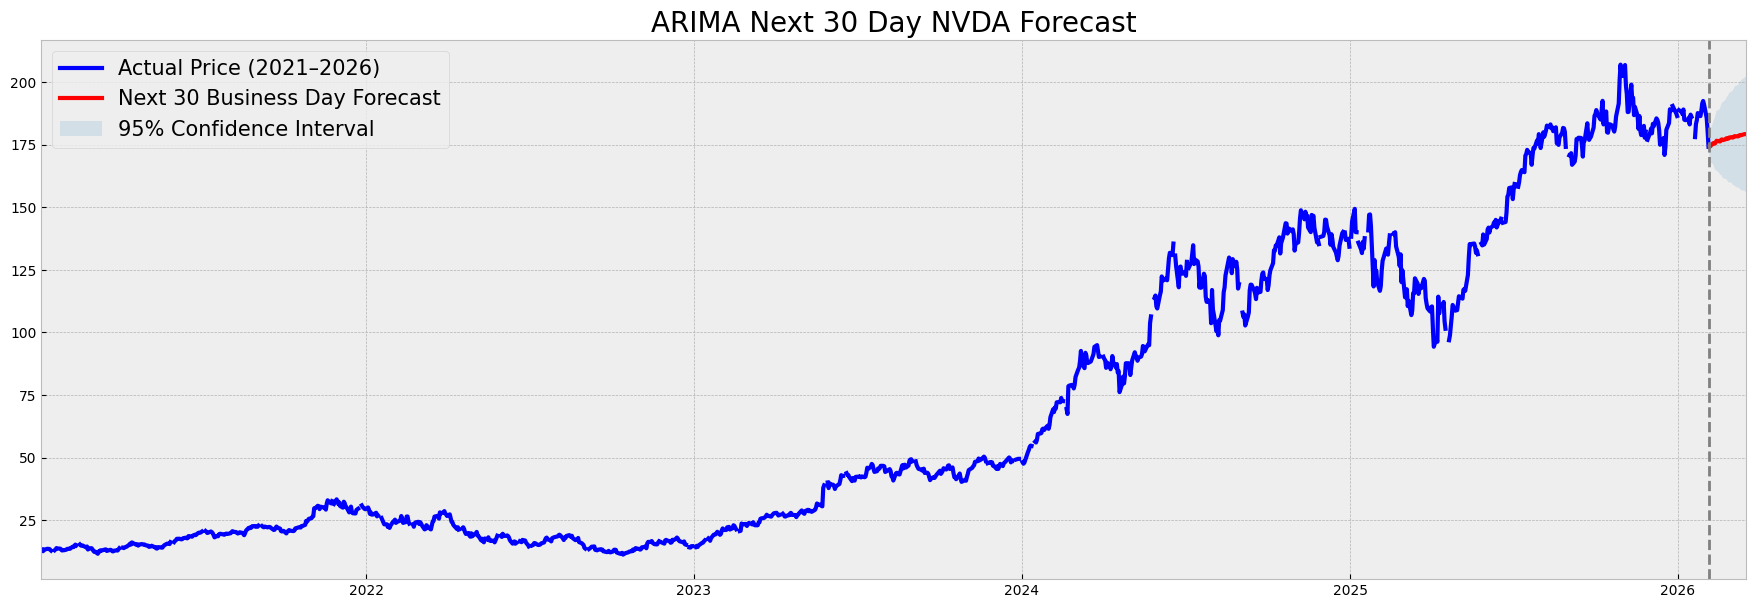

In [ ]:
plt.figure(figsize=(22,7))

plt.plot(arima_ts, label='Actual Price (2021–2026)',  linewidth=3, color='blue')
plt.plot(pred_30, label='Next 30 Business Day Forecast', linewidth=3, color='red')
plt.fill_between(
    ci_30.index,
    ci_30.iloc[:,0],
    ci_30.iloc[:,1],
    alpha=0.15,
    label='95% Confidence Interval',
)
plt.axvline(arima_ts.index[-1], linestyle='--', color='gray')
plt.xlim(arima_ts.index[0], pred_30.index[-1])
plt.legend(fontsize=15)
plt.title('ARIMA Next 30 Day NVDA Forecast', size=20)

plt.savefig(os.path.join(assets_folder_path, 'arima_next30Day_nvda_forecast.jpg'))
plt.show()

Zoom on Last Months + Forecast

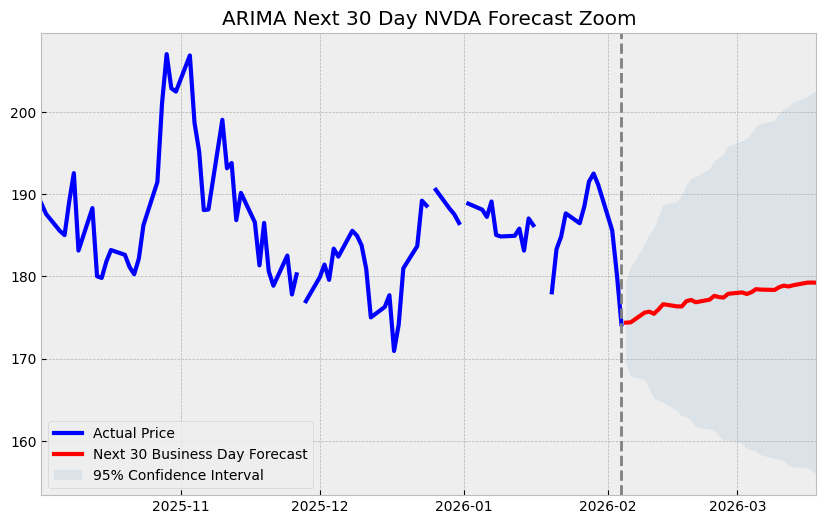

In [ ]:
start_zoom = arima_ts.index[-90]
end_zoom = ci_30.index[-1]

plt.figure(figsize=(10,6))

plt.plot(
    arima_ts.loc[start_zoom:],
    label ='Actual Price',
    linewidth=3,
    color='blue'
)

plt.plot(
    pred_30, label='Next 30 Business Day Forecast',  linewidth=3, color='red')

plt.fill_between(
    ci_30.index,
    ci_30.iloc[:,0],
    ci_30.iloc[:,1],
    alpha=.10,
    label='95% Confidence Interval',
)
plt.axvline(arima_ts.index[-1], linestyle='--', color='gray', linewidth=2)

plt.xlim(start_zoom, end_zoom)

plt.legend()
plt.title('ARIMA Next 30 Day NVDA Forecast Zoom')
plt.savefig(os.path.join(assets_folder_path, 'arima_next30Day_nvda_forecast_zoom.jpg'))
plt.show()

##### ARIMA Summary:
The ARIMA model captures the overall direction of the time series but struggles to represent short-term variability and volatility. While the model follows the long-term trend, forecast accuracy deteriorates as the prediction horizon increases. These results suggest that linear autoregressive structures alone may not fully capture the dynamics of NVDA price movements, motivating the exploration of machine learning models in the next section.